# Visual Place Cell Clustering

This notebook takes the raw observation dataset collected during habituation and produces a trained **Visual Place Cell (VPC) ensemble** by clustering the multimodal feature vectors. The resulting ensemble (cluster centers + radii) is saved to disk and used at runtime to compute place cell activations.

---

## Pipeline Overview

```
Habituation Controller
        ↓
data/vpce/habituation/<maze>.h5     ← raw observations (feature vectors + poses)
        ↓
    Clustering  (this notebook)
        ↓
data/vpce/place_cells/<maze>.h5     ← trained VPC ensemble (centers + radii)
```

## Habituation Dataset Structure

The habituation dataset is stored as an HDF5 file with the following structure:

| Dataset | Shape | Description |
|---|---|---|
| `multimodal_features` | `(N, feature_dim)` | Concatenated feature vectors across all 8 headings per position |
| `cnn_features` | `(N, cnn_dim)` | CNN features — omitted if not collected |
| `x` | `(N,)` | Robot x coordinate at time of observation |
| `y` | `(N,)` | Robot y coordinate at time of observation |
| `theta` | `(N,)` | Robot heading (degrees) at time of observation |

Each row `i` corresponds to one starting position in the maze. The `multimodal_features` vector is formed by concatenating HOG, color histogram, and spatial histogram descriptors extracted from images taken at 8 evenly spaced headings (0°, 45°, 90°, ..., 315°) at that position.

## Clustering Algorithms

Clustering maps the high-dimensional feature vectors into a set of **place cell centers** (cluster centroids) and **radii** (spread of each cluster). Two methods are available in `realm_tools.place_cell_lib.clustering`:

### K-Means
Partitions the feature space into `k` clusters by minimizing within-cluster variance. Each cluster centroid becomes a place cell center. The radius assigned to each cell is the **mean distance** from all points in that cluster to their centroid, giving a data-driven estimate of the receptive field size.

- **Pros:** Fast, deterministic (with fixed seed), scales well to large datasets.
- **Cons:** Assumes spherical clusters of equal size; single field per cell.

### Gaussian Mixture Model (GMM)
Models the feature distribution as a weighted sum of `k` Gaussians. Each Gaussian component becomes a place cell. The radius is approximated as the **square root of the mean diagonal covariance**, giving an isotropic estimate of the receptive field.

- **Pros:** Soft cluster assignments; can capture elliptical structure; naturally supports multi-field cells under high component counts.
- **Cons:** More expensive to fit; sensitive to initialisation.

Both functions share the same interface:
```python
centers, radii = fit_kmeans(features, n_clusters)
centers, radii = fit_gmm(features, n_components)
```

## Place Cell Activation Model

Once the ensemble is trained, each **Visual Place Cell** computes its activation via a **Radial Basis Function (RBF)** over the distance between a new observation's feature vector and the cell's stored centroid:

$$a_i = \exp\left(-\frac{\|\mathbf{f} - \mathbf{c}_i\|^2}{2\sigma_i^2}\right)$$

where:
- $\mathbf{f}$ is the feature vector of the current observation  
- $\mathbf{c}_i$ is the centroid of place cell $i$  
- $\sigma_i$ is the radius (receptive field width) of place cell $i$  

Activations are then **normalized** across the population so they sum to 1, producing a population vector that encodes the current location as a graded pattern of activity.

## Place Cell Ensemble — Saved Model Structure

The trained ensemble is stored as an HDF5 file under `data/vpce/place_cells/`:

| Dataset / Attribute | Type | Description |
|---|---|---|
| `centers` | `(N_cells, feature_dim)` | Cluster centroids in feature space |
| `radii` | `(N_cells,)` | RBF sigma per cell |
| `attrs['method']` | `str` | Clustering algorithm used (`'kmeans'` or `'gmm'`) |
| `attrs['maze']` | `str` | Maze the model was trained on (e.g. `'LM8'`) |
| `attrs['n_cells']` | `int` | Number of place cells |

---
## Configuration

In [1]:
import os
os.chdir('..')  # set working directory to project root

import numpy as np
import matplotlib.pyplot as plt

from realm_tools.experiment_lib.loggers import PovDataset, PlaceCellEnsemble
from realm_tools.place_cell_lib import fit_kmeans, fit_gmm

# --- Configuration ---

In [2]:
MAZE        = 'LM8_test'          # LM8 | LM8D | LMO8 | LMO8D
METHOD      = 'kmeans'       # 'kmeans' | 'gmm'
N_CELLS     = 10

DATA_PATH   = f'data/vpce/habituation/{MAZE}'
OUTPUT_PATH = f'data/vpce/place_cells/{MAZE}'

---
## Load Habituation Dataset

In [3]:
dataset = PovDataset.load_dataset(DATA_PATH)

features = np.array(dataset.multimodal_features)
poses    = np.stack([dataset.x, dataset.y, dataset.theta], axis=1)

print(f"Observations : {features.shape[0]}")
print(f"Feature dim  : {features.shape[1]}")
print(f"Pose shape   : {poses.shape}")

Observations : 30
Feature dim  : 58912
Pose shape   : (30, 3)


---
## Fit Place Cell Ensemble

In [4]:
if METHOD == 'kmeans':
    centers, radii = fit_kmeans(features, n_clusters=N_CELLS)
elif METHOD == 'gmm':
    centers, radii = fit_gmm(features, n_components=N_CELLS)
else:
    raise ValueError(f"Unknown method: {METHOD}")

print(f"Method  : {METHOD}")
print(f"Cells   : {len(centers)}")
print(f"Radii   — min: {radii.min():.4f}  max: {radii.max():.4f}  mean: {radii.mean():.4f}")

Method  : kmeans
Cells   : 10
Radii   — min: 1768.8315  max: 3365.8530  mean: 2617.2500


---
## Inspect Radii Distribution

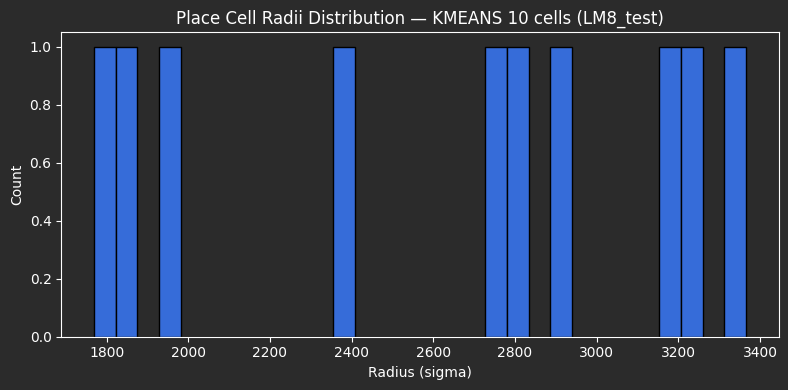

In [5]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(radii, bins=30, edgecolor='black')
ax.set_xlabel('Radius (sigma)')
ax.set_ylabel('Count')
ax.set_title(f'Place Cell Radii Distribution — {METHOD.upper()} {N_CELLS} cells ({MAZE})')
plt.tight_layout()
plt.show()

---
## Save Place Cell Ensemble

In [6]:
ensemble         = PlaceCellEnsemble()
ensemble.centers = centers
ensemble.radii   = radii
ensemble.save(OUTPUT_PATH, method=METHOD, maze=MAZE)

Place cell ensemble saved to data/vpce/place_cells/LM8_test.h5  (10 cells)
